In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import re
import os
import glob
import sys
from tqdm import tqdm
import datetime
import gc
import numpy as np
import tensorflow as tf

In [3]:
config = {
    'project_path': 'drive/MyDrive/author-handwriting-recog',
    'dataset': 'complete_dataset_20260122-142244.tar.gz',
    'authors_range': range(180),
    'input_shape': (60, 53, 1),
    'embedding_dim': 256,
    'epochs': 10,
    'seed': 42,
}

In [4]:
sys.path.insert(0, config['project_path'])

In [5]:
sys.path

['drive/MyDrive/author-handwriting-recog',
 '/content',
 '/env/python',
 '/usr/lib/python312.zip',
 '/usr/lib/python3.12',
 '/usr/lib/python3.12/lib-dynload',
 '',
 '/usr/local/lib/python3.12/dist-packages',
 '/usr/lib/python3/dist-packages',
 '/usr/local/lib/python3.12/dist-packages/IPython/extensions',
 '/root/.ipython']

In [6]:
!pip install "zarr>=2.16.0,<3.0.0" numcodecs

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.3/211.3 kB 17.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 111.9 MB/s eta 0:00:00
  Created wheel for asciitree: filename=asciitree-0.3.3-py3-none-any.whl size=5031 sha256=490e6f6e2d4e9aa6a0dd38288bc58aa0e142c439e960a09e1fe780680f11a97e
  Stored in directory: /root/.cache/pip/wheels/a5/d7/98/f56ae733748cd0fa577172bda0e73e0b1f1793c98e09b9e458
Successfully built asciitree


In [7]:
from src.io.exceptions import DeserializationError
from src.io.logging import LoggerFactory
from src import SelectiveDataLoader
from src.io import load

In [8]:
dataset_path = f"{config['project_path']}/data/datasets/{config['dataset']}"

In [9]:
current_time = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")

In [10]:
logger = LoggerFactory.get_notebook_logger("code_1", log_dir=f"./logs_{current_time}")

In [11]:
!tar -xzf {dataset_path} -C ./

In [12]:
loader = SelectiveDataLoader(
        dataset_path="./complete_dataset_20260122-142244.zarr",
        load_fn=load
        )

19:17:25 - ZarrSerializer - INFO - Initialized with blosc compression (level 5)
19:17:25 - ZarrSerializer - INFO - ======================================================================
19:17:25 - ZarrSerializer - INFO - Loading Zarr dataset: complete_dataset_20260122-142244.zarr
19:17:25 - ZarrSerializer - INFO - ======================================================================
19:17:25 - ZarrSerializer - INFO - 📂 Loading partition (lazy mode)...
19:17:25 - ZarrSerializer - INFO -    ├─ train: 1,268,876 patches (~34851MB, lazy-loaded)
19:17:25 - ZarrSerializer - INFO -    ├─ validation: 206,216 patches (~5664MB, lazy-loaded)
19:17:25 - ZarrSerializer - INFO -    ├─ test: 51,067 patches (~1403MB, lazy-loaded)
19:17:25 - ZarrSerializer - INFO -    └─ Partition loaded (data not yet in memory)
19:17:25 - ZarrSerializer - INFO - 📂 Loading 'labels': (1526159,), 5.8MB
19:17:25 - ZarrSerializer - INFO - 📂 Loading metadata: 5 items
19:17:25 - ZarrSerializer - INFO - ======================

In [13]:
from src.datasets import SubsetBuilder, PairGenerator, DataGenerator, TripletGenerator

In [14]:
subset_builder = SubsetBuilder(
    loader=loader,
)

In [15]:
subset = subset_builder.build(
    authors_range=config['authors_range'],
    show_progress_bar=True,
)

19:17:25 - ZarrSerializer - INFO - ======================================================================
19:17:25 - ZarrSerializer - INFO - Loading Zarr dataset: complete_dataset_20260122-142244.zarr
19:17:25 - ZarrSerializer - INFO - ======================================================================
19:17:25 - ZarrSerializer - INFO - 📂 Loading partition (lazy mode)...
19:17:25 - ZarrSerializer - INFO -    ├─ train: 1,268,876 patches (~34851MB, lazy-loaded)
19:17:25 - ZarrSerializer - INFO -    ├─ validation: 206,216 patches (~5664MB, lazy-loaded)
19:17:25 - ZarrSerializer - INFO -    ├─ test: 51,067 patches (~1403MB, lazy-loaded)
19:17:25 - ZarrSerializer - INFO -    └─ Partition loaded (data not yet in memory)
19:17:25 - ZarrSerializer - INFO - 📂 Loading 'labels': (1526159,), 5.8MB
19:17:25 - ZarrSerializer - INFO - 📂 Loading metadata: 5 items
19:17:25 - ZarrSerializer - INFO - ======================================================================
19:17:25 - ZarrSerializer - INF

Loading train: 100%|██████████| 180/180 [00:58<00:00,  3.05it/s]


19:18:30 - ZarrSerializer - INFO - ======================================================================
19:18:30 - ZarrSerializer - INFO - Loading Zarr dataset: complete_dataset_20260122-142244.zarr
19:18:30 - ZarrSerializer - INFO - ======================================================================
19:18:30 - ZarrSerializer - INFO - 📂 Loading partition (lazy mode)...
19:18:30 - ZarrSerializer - INFO -    ├─ train: 1,268,876 patches (~34851MB, lazy-loaded)
19:18:30 - ZarrSerializer - INFO -    ├─ validation: 206,216 patches (~5664MB, lazy-loaded)
19:18:30 - ZarrSerializer - INFO -    ├─ test: 51,067 patches (~1403MB, lazy-loaded)
19:18:30 - ZarrSerializer - INFO -    └─ Partition loaded (data not yet in memory)
19:18:30 - ZarrSerializer - INFO - 📂 Loading 'labels': (1526159,), 5.8MB
19:18:30 - ZarrSerializer - INFO - 📂 Loading metadata: 5 items
19:18:30 - ZarrSerializer - INFO - ======================================================================
19:18:30 - ZarrSerializer - INF

Loading validation: 100%|██████████| 180/180 [00:08<00:00, 21.52it/s]


19:18:39 - ZarrSerializer - INFO - ======================================================================
19:18:39 - ZarrSerializer - INFO - Loading Zarr dataset: complete_dataset_20260122-142244.zarr
19:18:39 - ZarrSerializer - INFO - ======================================================================
19:18:39 - ZarrSerializer - INFO - 📂 Loading partition (lazy mode)...
19:18:39 - ZarrSerializer - INFO -    ├─ train: 1,268,876 patches (~34851MB, lazy-loaded)
19:18:39 - ZarrSerializer - INFO -    ├─ validation: 206,216 patches (~5664MB, lazy-loaded)
19:18:39 - ZarrSerializer - INFO -    ├─ test: 51,067 patches (~1403MB, lazy-loaded)
19:18:39 - ZarrSerializer - INFO -    └─ Partition loaded (data not yet in memory)
19:18:39 - ZarrSerializer - INFO - 📂 Loading 'labels': (1526159,), 5.8MB
19:18:39 - ZarrSerializer - INFO - 📂 Loading metadata: 5 items
19:18:39 - ZarrSerializer - INFO - ======================================================================
19:18:39 - ZarrSerializer - INF

Loading test: 100%|██████████| 180/180 [00:02<00:00, 87.07it/s]


In [16]:
train_triplet_gen = TripletGenerator(
    data=subset.splits['train'],
    batch_size=256,
    shuffle=True,
    use_augmentation=True,
    seed=config['seed']
)

In [17]:
val_triplet_gen = TripletGenerator(
    data=subset.splits['validation'],
    batch_size=64,
    use_augmentation=False,
    shuffle=False,
)

In [18]:
test_triplet_gen = TripletGenerator(
    data=subset.splits['test'],
    batch_size=32,
    use_augmentation=False,
    shuffle=False,
)

In [19]:
len(train_triplet_gen), len(val_triplet_gen), len(test_triplet_gen)

(2188, 1423, 707)

In [20]:
logger.info(f"Train samples: {train_triplet_gen.num_patches}")
logger.info(f"Validation samples: {val_triplet_gen.num_patches}")
logger.info(f"Test samples: {test_triplet_gen.num_patches}")
logger.info(f"Ratio: {train_triplet_gen.num_patches / val_triplet_gen.num_patches:.2f}")

INFO - Train samples: 560070
INFO - Validation samples: 91039
INFO - Test samples: 22594
INFO - Ratio: 6.15


In [21]:
train_stats = train_triplet_gen.get_statistics()
logger.info(f"Train samples: {train_stats["total_patches"]}")
logger.info(f"Avg patches per author: {train_stats["avg_patches_per_author"]:.2f}")
logger.info(f"Min patches per author: {train_stats["min_patches"]}")
logger.info(f"Max patches per author: {train_stats["max_patches"]}")

INFO - Train samples: 560070
INFO - Avg patches per author: 3111.50
INFO - Min patches per author: 792
INFO - Max patches per author: 3269


In [22]:
val_stats = val_triplet_gen.get_statistics()
logger.info(f"Val samples: {val_stats["total_patches"]}")
logger.info(f"Avg patches per author: {val_stats["avg_patches_per_author"]:.2f}")
logger.info(f"Min patches per author: {val_stats["min_patches"]}")
logger.info(f"Max patches per author: {val_stats["max_patches"]}")

INFO - Val samples: 91039
INFO - Avg patches per author: 505.77
INFO - Min patches per author: 143
INFO - Max patches per author: 533


In [23]:
test_stats = test_triplet_gen.get_statistics()
logger.info(f"Val samples: {test_stats["total_patches"]}")
logger.info(f"Avg patches per author: {test_stats["avg_patches_per_author"]:.2f}")
logger.info(f"Min patches per author: {test_stats["min_patches"]}")
logger.info(f"Max patches per author: {test_stats["max_patches"]}")

INFO - Val samples: 22594
INFO - Avg patches per author: 125.52
INFO - Min patches per author: 92
INFO - Max patches per author: 143


In [24]:
from src.models import (
    CNNBackbone,
    CNNTransformerBackbone,
    DeepCNNBackbone,
    build_siamese_model,
    build_embedding_model,
    ContrastiveLoss,
    BinaryCrossEntropyDistance,
    TripletLoss,
)
from src.models.training import ModelTrainer, get_default_callbacks
from src.models.evaluation import (
    ModelComparator,
    ModelEvaluator,
    plot_training_history,
    plot_comparison_metrics,
    plot_embeddings_tsne
)

In [25]:
backbone = DeepCNNBackbone()

In [26]:
cnn_trainer = ModelTrainer(
    backbone=backbone,
    input_shape=config['input_shape'],
    embedding_dim=config['embedding_dim'],
    model_name="siamese_cnn_triplet",
    log_dir=f"./logs_{current_time}"
)

19:18:44 - siamese_cnn_triplet_trainer - INFO - Model trainer initialized: siamese_cnn_triplet
19:18:44 - siamese_cnn_triplet_trainer - INFO - Input shape: (60, 53, 1)
19:18:44 - siamese_cnn_triplet_trainer - INFO - Embedding dim: 256


In [27]:
cnn_trainer.build(model_type="triplet")

19:18:44 - siamese_cnn_triplet_trainer - INFO - Building models...
19:18:45 - siamese_cnn_triplet_trainer - INFO - Model built: triplet_model
19:18:45 - siamese_cnn_triplet_trainer - INFO - Total params: 3391296
19:18:45 - siamese_cnn_triplet_trainer - INFO - Trainable params: 3388544


In [28]:
cnn_trainer.embedding_model.summary()

Model: "siamese_cnn_triplet_embedding_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 60, 53, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 60, 53, 96)     │           960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 60, 53, 96)     │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 60, 53, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 30, 26, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 30, 26, 256)    │       221,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 30, 26, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 30, 26, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 15, 13, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 15, 13, 384)    │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 15, 13, 384)    │         1,536 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 15, 13, 384)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 7, 6, 384)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 7, 6, 384)      │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 7, 6, 384)      │         1,536 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 7, 6, 384)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 7, 6, 256)      │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 7, 6, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_4 (ReLU)                  │ (None, 7, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 3, 3, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_projection (Dense)    │ (None, 256)            │        65,79

 Total params: 3,391,296 (12.94 MB)

 Trainable params: 3,388,544 (12.93 MB)

 Non-trainable params: 2,752 (10.75 KB)

In [29]:
cnn_trainer.siamese_model.summary()

Model: "triplet_model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ anchor_input        │ (None, 60, 53, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ positive_input      │ (None, 60, 53, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ negative_input      │ (None, 60, 53, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ siamese_cnn_triple… │ (None, 256)       │  3,391,296 │ anchor_input[0][… │
│ (Functional)        │                   │            │ positive_input[0… │
│                     │                   │            │ negative_input[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 3, 256)    │          0 │ siamese_cnn_trip… │
│                     │                   │            │ siamese_cnn_trip… │
│                     │                   │            │ siamese_cnn_trip… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 3,391,296 (12.94 MB)

 Trainable params: 3,388,544 (12.93 MB)

 Non-trainable params: 2,752 (10.75 KB)

In [30]:
cnn_trainer.compile(loss=TripletLoss(margin=1.0))

19:18:45 - siamese_cnn_triplet_trainer - INFO - Compiling model...
19:18:45 - siamese_cnn_triplet_trainer - INFO - Model compiled
19:18:45 - siamese_cnn_triplet_trainer - INFO -   - Optimizer: Adam
19:18:45 - siamese_cnn_triplet_trainer - INFO -   - Learning rate: 0.0001
19:18:45 - siamese_cnn_triplet_trainer - INFO -   - Loss: TripletLoss
19:18:45 - siamese_cnn_triplet_trainer - INFO -   - Loss margin: 1.0


In [31]:
callbacks = get_default_callbacks(
    model_name="siamese_cnn",
    patience=4,
    reduce_lr_patience=2,
)

In [32]:
train_ds, train_steps = train_triplet_gen.to_dataset()

In [33]:
val_ds, val_steps = val_triplet_gen.to_dataset()

In [34]:
train_steps, val_steps

(2188, 1423)

In [35]:
cnn_history = cnn_trainer.train(
    train_generator=train_ds,
    val_generator=val_ds,
    steps_per_epoch=train_steps,
    validation_steps=val_steps,
    epochs=config['epochs'],
    callbacks=callbacks,
    verbose=1
)

19:18:45 - siamese_cnn_triplet_trainer - INFO - Starting training for 10 epochs...
19:18:45 - siamese_cnn_triplet_trainer - INFO -   - Train batches: 2188
19:18:45 - siamese_cnn_triplet_trainer - INFO -   - Val batches: 1423
Epoch 1/10
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 0s 274ms/step - loss: 0.8664
Epoch 1: val_loss improved from inf to 0.75378, saving model to checkpoints/siamese_cnn/best.keras
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 662s 292ms/step - loss: 0.8664 - val_loss: 0.7538 - learning_rate: 1.0000e-04
Epoch 2/10
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 0s 285ms/step - loss: 0.7947
Epoch 2: val_loss improved from 0.75378 to 0.73219, saving model to checkpoints/siamese_cnn/best.keras
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 661s 302ms/step - loss: 0.7947 - val_loss: 0.7322 - learning_rate: 1.0000e-04
Epoch 3/10
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 0s 283ms/step - loss: 0.7751
Epoch 3: val_loss improved from 0.73219 to 0.71944, saving model to checkpoints/siamese_cnn/best.keras
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 660s 302

KeyboardInterrupt: 

In [ ]:
import matplotlib.pyplot as plt

def plot_training_loss(history, title="Training Loss"):
    loss = history.history["loss"]
    val_loss = history.history.get("val_loss")

    plt.figure(figsize=(8, 5))
    plt.plot(loss, label="Train Loss")
    if val_loss is not None:
        plt.plot(val_loss, label="Validation Loss")

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

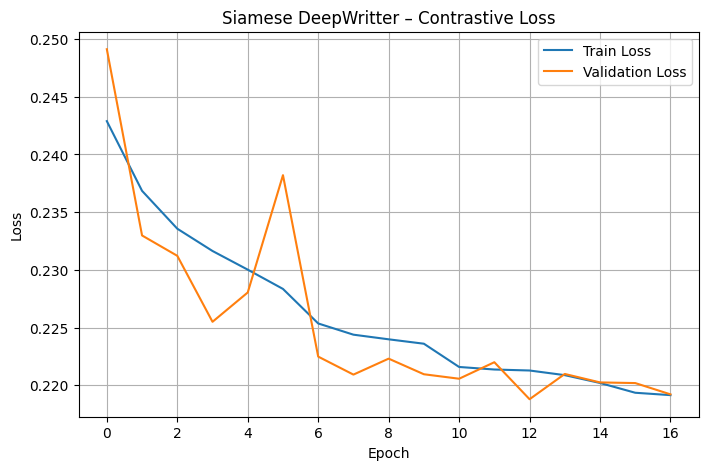

In [ ]:
plot_training_loss(
    cnn_history,
    title="Siamese DeepWritter – Contrastive Loss"
)

In [36]:
cnn_trainer.save(f"./models/siamese_triplet_cnn_{current_time}.keras")

20:14:10 - siamese_cnn_triplet_trainer - INFO - Model saved to models/siamese_triplet_cnn_20260202-191620.keras


In [43]:
cnn_trainer_new = ModelTrainer(
    backbone=DeepCNNBackbone(),
    input_shape=config['input_shape'],
    embedding_dim=config['embedding_dim'],
    model_name="siamese_cnn_triplet",
    log_dir=f"./logs_{current_time}"
)
cnn_trainer_new.build(model_type="triplet")

20:15:50 - siamese_cnn_triplet_trainer - INFO - Model trainer initialized: siamese_cnn_triplet
20:15:50 - siamese_cnn_triplet_trainer - INFO - Input shape: (60, 53, 1)
20:15:50 - siamese_cnn_triplet_trainer - INFO - Embedding dim: 256
20:15:50 - siamese_cnn_triplet_trainer - INFO - Building models...
20:15:50 - siamese_cnn_triplet_trainer - INFO - Model built: triplet_model
20:15:50 - siamese_cnn_triplet_trainer - INFO - Total params: 3391296
20:15:50 - siamese_cnn_triplet_trainer - INFO - Trainable params: 3388544


In [44]:
cnn_trainer_new.siamese_model.load_weights(
    f"./models/siamese_triplet_cnn_{current_time}.keras"
)

In [45]:
cnn_evaluator = ModelEvaluator(
    model=cnn_trainer_new.siamese_model,
    model_name="siamese_cnn_triplet",
    embedding_model=cnn_trainer_new.embedding_model,
    model_type="triplet",
    log_dir=f"./logs_{current_time}"
)

In [46]:
cnn_evaluator.model.summary()

Model: "triplet_model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ anchor_input        │ (None, 60, 53, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ positive_input      │ (None, 60, 53, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ negative_input      │ (None, 60, 53, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ siamese_cnn_triple… │ (None, 256)       │  3,391,296 │ anchor_input[0][… │
│ (Functional)        │                   │            │ positive_input[0… │
│                     │                   │            │ negative_input[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack_2 (Stack)     │ (None, 3, 256)    │          0 │ siamese_cnn_trip… │
│                     │                   │            │ siamese_cnn_trip… │
│                     │                   │            │ siamese_cnn_trip… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 3,391,296 (12.94 MB)

 Trainable params: 3,388,544 (12.93 MB)

 Non-trainable params: 2,752 (10.75 KB)

In [47]:
cnn_evaluator.embedding_model.summary()

Model: "siamese_cnn_triplet_embedding_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 60, 53, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 60, 53, 96)     │           960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 60, 53, 96)     │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_10 (ReLU)                 │ (None, 60, 53, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 30, 26, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 30, 26, 256)    │       221,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 30, 26, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_11 (ReLU)                 │ (None, 30, 26, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 15, 13, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 15, 13, 384)    │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 15, 13, 384)    │         1,536 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_12 (ReLU)                 │ (None, 15, 13, 384)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 7, 6, 384)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 7, 6, 384)      │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 7, 6, 384)      │         1,536 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_13 (ReLU)                 │ (None, 7, 6, 384)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 7, 6, 256)      │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 7, 6, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_14 (ReLU)                 │ (None, 7, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 3, 3, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_projection (Dense)    │ (None, 256)            │        65,79

 Total params: 3,391,296 (12.94 MB)

 Trainable params: 3,388,544 (12.93 MB)

 Non-trainable params: 2,752 (10.75 KB)

In [48]:
test_ds, test_steps = test_triplet_gen.to_dataset()

In [49]:
test_results = cnn_evaluator.evaluate(
    test_generator=test_ds,
    steps=test_steps,
    distance_threshold=1.0,
)

20:16:20 - siamese_cnn_triplet_evaluator - INFO - Evaluating siamese_cnn_triplet...
20:17:18 - siamese_cnn_triplet_evaluator - INFO - Evaluation completed:
20:17:18 - siamese_cnn_triplet_evaluator - INFO -   - Accuracy:  0.7378
20:17:18 - siamese_cnn_triplet_evaluator - INFO -   - AUC:       0.8164
20:17:18 - siamese_cnn_triplet_evaluator - INFO -   - Precision: 0.7152
20:17:18 - siamese_cnn_triplet_evaluator - INFO -   - Recall:    0.7904
20:17:18 - siamese_cnn_triplet_evaluator - INFO -   - F1-Score:  0.7509


In [50]:
distances = test_results['distances']
y_true = test_results['y_true']

In [51]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_true, 1 - (distances / distances.max()))
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx] * distances.max()

logger.info(f"\nOptimal threshold: {optimal_threshold:.4f}")

INFO - 
Optimal threshold: 0.9230


INFO - Positive pairs - mean: 0.7649, std: 0.2890
INFO - Negative pairs - mean: 1.1792, std: 0.3410


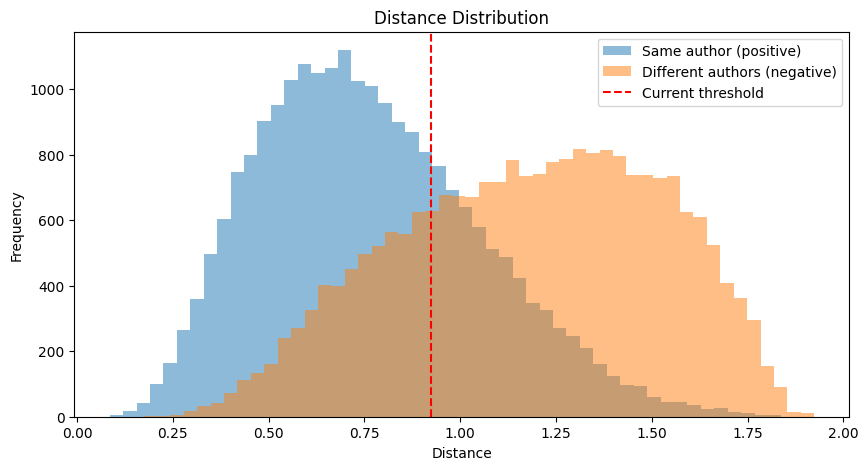

In [52]:
import matplotlib.pyplot as plt

pos_distances = distances[y_true == 1]
neg_distances = distances[y_true == 0]

logger.info(f"Positive pairs - mean: {pos_distances.mean():.4f}, std: {pos_distances.std():.4f}")
logger.info(f"Negative pairs - mean: {neg_distances.mean():.4f}, std: {neg_distances.std():.4f}")

# Plot histograma
plt.figure(figsize=(10, 5))
plt.hist(pos_distances, bins=50, alpha=0.5, label='Same author (positive)')
plt.hist(neg_distances, bins=50, alpha=0.5, label='Different authors (negative)')
plt.axvline(x=optimal_threshold, color='r', linestyle='--', label='Current threshold')
plt.xlabel('Distance')
plt.ylabel('Frequency')
plt.legend()
plt.title('Distance Distribution')
plt.show()

In [53]:
from src.datasets import DataGenerator

In [54]:
test_gen = DataGenerator(
    data=subset.splits['test'],
    batch_size=16,
    use_augmentation=False,
    shuffle=False
)

In [55]:
test_ds, test_steps = test_gen.to_dataset()

In [56]:
all_embeddings: list[np.ndarray] = []
all_author_ids: list[np.ndarray] = []

for X, y in test_ds.take(test_steps):
    emb = cnn_evaluator.embedding_model.predict(X, verbose=0)
    all_embeddings.append(emb)
    all_author_ids.append(y)

embeddings = np.concatenate(all_embeddings, axis=0)   # (N, D)
author_ids = np.concatenate(all_author_ids, axis=0)   # (N,)

In [57]:
from collections import defaultdict

def build_gallery(
    embeddings: np.ndarray,
    author_ids: np.ndarray,
) -> dict[int, np.ndarray]:

    by_author: dict[int, list[np.ndarray]] = defaultdict(list)

    for emb, author_id in zip(embeddings, author_ids):
        by_author[int(author_id)].append(emb)

    gallery = {
        author_id: np.mean(np.stack(author_embs), axis=0)
        for author_id, author_embs in by_author.items()
    }

    return gallery

In [58]:
gallery = build_gallery(embeddings, author_ids)

In [59]:
def identify_author(
    author_embeddings: np.ndarray,
    gallery: dict[int, np.ndarray],
) -> dict[str, any]:

    scores: dict[int, float] = {}

    for author_id, gallery_emb in gallery.items():
        distances = np.linalg.norm(author_embeddings - gallery_emb, axis=1)
        scores[author_id] = float(distances.mean())

    pred_author = min(scores, key=scores.get)

    return {
        "pred_author_id": pred_author,
        "scores": scores,
        "mean_distance": scores[pred_author],
    }

In [60]:
from sklearn.metrics import accuracy_score

def evaluate_identification(
    embeddings: np.ndarray,
    author_ids: np.ndarray,
    gallery: dict[int, np.ndarray],
    min_patches: int = 3,
) -> dict[str, any]:

    y_true: list[int] = []
    y_pred: list[int] = []
    details: list[dict[str, any]] = []

    for author_id in np.unique(author_ids):
        idx = np.where(author_ids == author_id)[0]

        if len(idx) < min_patches:
            continue

        author_embs = embeddings[idx]
        res = identify_author(author_embs, gallery)

        y_true.append(author_id)
        y_pred.append(res["pred_author_id"])

        details.append({
            "true_author_id": author_id,
            "pred_author_id": res["pred_author_id"],
            "correct": author_id == res["pred_author_id"],
            "mean_distance": res["mean_distance"],
        })

    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "num_authors": len(y_true),
        "details": details,
    }

In [61]:
import pandas as pd

def identification_results_to_df(res: dict) -> pd.DataFrame:
    """
    Convert identification results to a per-author DataFrame.
    """
    df = pd.DataFrame(res["details"])

    # Ensure proper dtypes
    df["true_author_id"] = df["true_author_id"].astype(int)
    df["pred_author_id"] = df["pred_author_id"].astype(int)
    df["correct"] = df["correct"].astype(bool)
    df["mean_distance"] = df["mean_distance"].astype(float)

    return df

In [62]:
def extract_identification_summary(res: dict) -> dict[str, float | int]:
    """
    Extract high-level identification metrics.
    """
    return {
        "accuracy": res["accuracy"],
        "num_authors": res["num_authors"],
    }

In [63]:
identification_results = evaluate_identification(
    embeddings,
    author_ids,
    gallery,
)

In [64]:
res = identification_results_to_df(identification_results)
summary = extract_identification_summary(identification_results)

In [65]:
logger.info(f"Identification summary: {summary}")

INFO - Identification summary: {'accuracy': 1.0, 'num_authors': 180}


In [66]:
res

,true_author_id,pred_author_id,correct,mean_distance
0,0,0,True,0.350154
1,1,1,True,0.382316
2,2,2,True,0.493828
3,3,3,True,0.606980
4,4,4,True,0.729085
...,...,...,...,...
175,175,175,True,0.488003
176,176,176,True,0.475252
177,177,177,True,0.674136
178,178,178,True,0.496706


In [67]:
def voting_for_author(
    embeddings: np.ndarray,
    distance_threshold: float,
) -> dict[str, any]:

    votes_same, votes_diff = 0, 0
    distances = []

    for i in range(len(embeddings)):
        for j in range(i + 1, len(embeddings)):
            d = np.linalg.norm(embeddings[i] - embeddings[j])
            distances.append(d)

            if d < distance_threshold:
                votes_same += 1
            else:
                votes_diff += 1

    total = votes_same + votes_diff

    return {
        "votes_same": votes_same,
        "votes_diff": votes_diff,
        "confidence": votes_same / total if total > 0 else 0.0,
        "mean_distance": float(np.mean(distances)),
        "std_distance": float(np.std(distances)),
        "num_pairs": total,
    }

In [68]:
def evaluate_voting(
    embeddings: np.ndarray,
    author_ids: np.ndarray,
    distance_threshold: float,
    min_patches: int = 3,
) -> dict[str, any]:

    details = []

    for author_id in np.unique(author_ids):
        idx = np.where(author_ids == author_id)[0]

        if len(idx) < min_patches:
            continue

        res = voting_for_author(
            embeddings[idx],
            distance_threshold,
        )

        details.append({
            "author_id": author_id,
            **res,
        })

    return {
        "num_authors": len(details),
        "details": details,
    }

In [69]:
import pandas as pd

def voting_results_to_df(res: dict) -> pd.DataFrame:
    """
    Convert identification results to a per-author DataFrame.
    """
    df = pd.DataFrame(res["details"])

    # Ensure proper dtypes
    df["author_id"] = df["author_id"].astype(int)
    df["votes_same"] = df["votes_same"].astype(int)
    df["votes_diff"] = df["votes_diff"].astype(int)
    df["confidence"] = df["confidence"].astype(float)
    df["mean_distance"] = df["mean_distance"].astype(float)
    df["std_distance"] = df["std_distance"].astype(float)
    df["num_pairs"] = df["num_pairs"].astype(int)

    return df

In [71]:
voting_results = evaluate_voting(
    embeddings,
    author_ids,
    distance_threshold=1.0
)

In [72]:
v_results = voting_results_to_df(voting_results)

In [73]:
v_results

,author_id,votes_same,votes_diff,confidence,mean_distance,std_distance,num_pairs
0,0,5746,32,0.994462,0.494698,0.166217,5778
1,1,7463,40,0.994669,0.539362,0.165347,7503
2,2,7103,1412,0.834175,0.697498,0.295428,8515
3,3,6282,2898,0.684314,0.856605,0.294991,9180
4,4,3794,4207,0.474191,1.015502,0.303513,8001
...,...,...,...,...,...,...,...
175,175,7041,1215,0.852834,0.691622,0.273028,8256
176,176,6112,443,0.932418,0.669148,0.205311,6555
177,177,3635,2581,0.584781,0.948492,0.306677,6216
178,178,6044,742,0.890657,0.702483,0.223329,6786


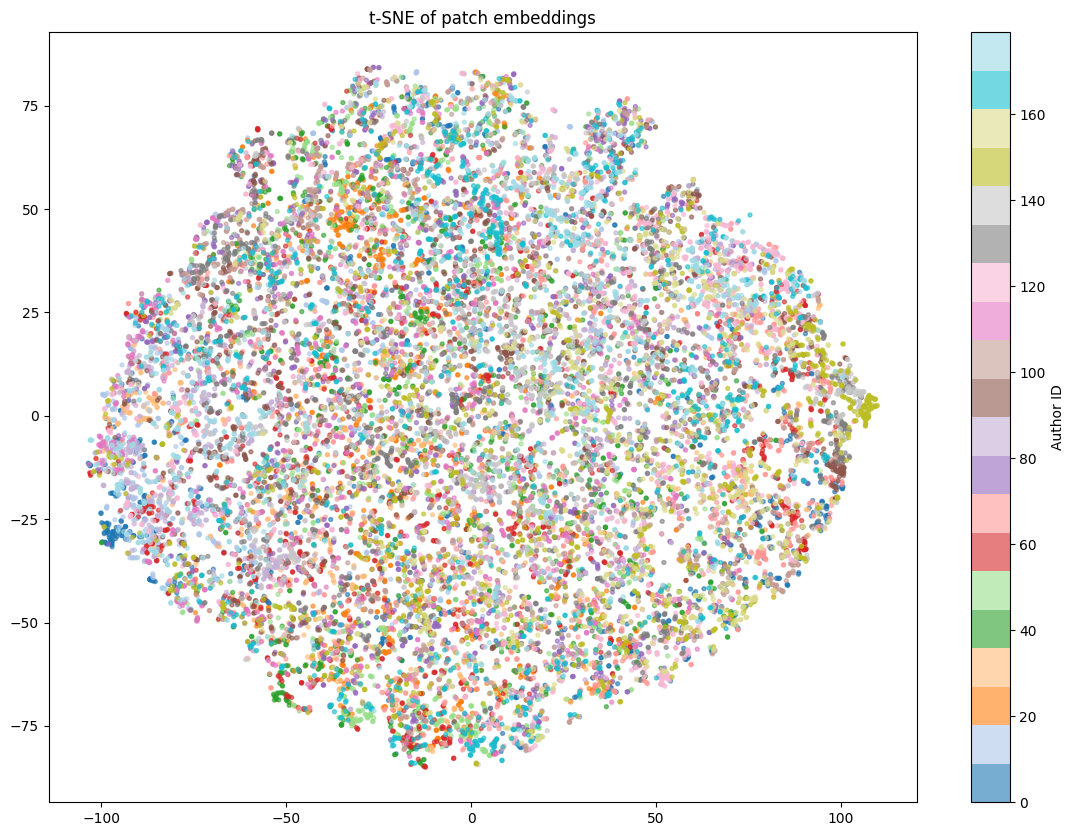

In [74]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

tsne = TSNE(
    n_components=2,
    perplexity=30,
    max_iter=1000,
    random_state=42,
)

emb_2d = tsne.fit_transform(embeddings)

plt.figure(figsize=(14, 10))
plt.scatter(
    emb_2d[:, 0],
    emb_2d[:, 1],
    c=author_ids,
    cmap="tab20",
    s=8,
    alpha=0.6,
)
plt.colorbar(label="Author ID")
plt.title("t-SNE of patch embeddings")
plt.show()

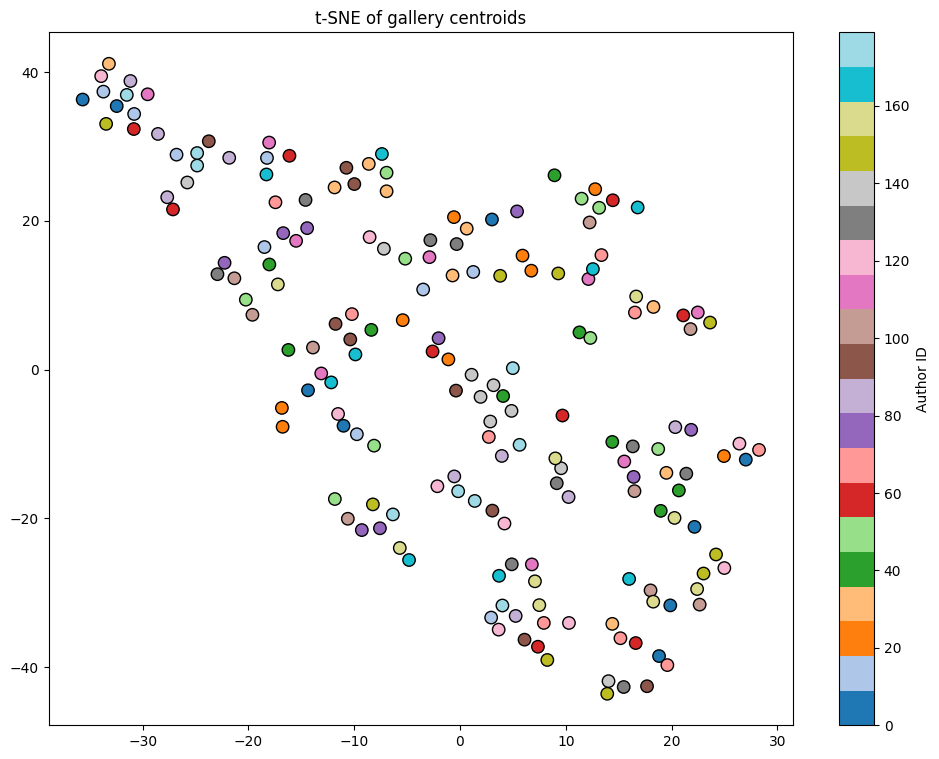

In [75]:
gallery_embeddings = np.stack(list(gallery.values()))
gallery_author_ids = np.array(list(gallery.keys()))

tsne = TSNE(
    n_components=2,
    perplexity=10,
    max_iter=1000,
    random_state=42,
)

gallery_2d = tsne.fit_transform(gallery_embeddings)

plt.figure(figsize=(12, 9))
plt.scatter(
    gallery_2d[:, 0],
    gallery_2d[:, 1],
    c=gallery_author_ids,
    cmap="tab20",
    s=80,
    edgecolors="black",
)
plt.colorbar(label="Author ID")
plt.title("t-SNE of gallery centroids")
plt.show()

In [76]:
eval_subset = subset_builder.build(
    authors_range=range(180, 204),
    show_progress_bar=True,
)

20:22:40 - ZarrSerializer - INFO - ======================================================================
20:22:40 - ZarrSerializer - INFO - Loading Zarr dataset: complete_dataset_20260122-142244.zarr
20:22:40 - ZarrSerializer - INFO - ======================================================================
20:22:40 - ZarrSerializer - INFO - 📂 Loading partition (lazy mode)...
20:22:40 - ZarrSerializer - INFO -    ├─ train: 1,268,876 patches (~34851MB, lazy-loaded)
20:22:40 - ZarrSerializer - INFO -    ├─ validation: 206,216 patches (~5664MB, lazy-loaded)
20:22:40 - ZarrSerializer - INFO -    ├─ test: 51,067 patches (~1403MB, lazy-loaded)
20:22:40 - ZarrSerializer - INFO -    └─ Partition loaded (data not yet in memory)
20:22:41 - ZarrSerializer - INFO - 📂 Loading 'labels': (1526159,), 5.8MB
20:22:41 - ZarrSerializer - INFO - 📂 Loading metadata: 5 items
20:22:41 - ZarrSerializer - INFO - ======================================================================
20:22:41 - ZarrSerializer - INF

Loading train: 100%|██████████| 24/24 [00:06<00:00,  3.63it/s]


20:22:48 - ZarrSerializer - INFO - ======================================================================
20:22:48 - ZarrSerializer - INFO - Loading Zarr dataset: complete_dataset_20260122-142244.zarr
20:22:48 - ZarrSerializer - INFO - ======================================================================
20:22:48 - ZarrSerializer - INFO - 📂 Loading partition (lazy mode)...
20:22:48 - ZarrSerializer - INFO -    ├─ train: 1,268,876 patches (~34851MB, lazy-loaded)
20:22:48 - ZarrSerializer - INFO -    ├─ validation: 206,216 patches (~5664MB, lazy-loaded)
20:22:48 - ZarrSerializer - INFO -    ├─ test: 51,067 patches (~1403MB, lazy-loaded)
20:22:48 - ZarrSerializer - INFO -    └─ Partition loaded (data not yet in memory)
20:22:48 - ZarrSerializer - INFO - 📂 Loading 'labels': (1526159,), 5.8MB
20:22:48 - ZarrSerializer - INFO - 📂 Loading metadata: 5 items
20:22:48 - ZarrSerializer - INFO - ======================================================================
20:22:48 - ZarrSerializer - INF

Loading validation: 100%|██████████| 24/24 [00:00<00:00, 24.05it/s]


20:22:50 - ZarrSerializer - INFO - ======================================================================
20:22:50 - ZarrSerializer - INFO - Loading Zarr dataset: complete_dataset_20260122-142244.zarr
20:22:50 - ZarrSerializer - INFO - ======================================================================
20:22:50 - ZarrSerializer - INFO - 📂 Loading partition (lazy mode)...
20:22:50 - ZarrSerializer - INFO -    ├─ train: 1,268,876 patches (~34851MB, lazy-loaded)
20:22:50 - ZarrSerializer - INFO -    ├─ validation: 206,216 patches (~5664MB, lazy-loaded)
20:22:50 - ZarrSerializer - INFO -    ├─ test: 51,067 patches (~1403MB, lazy-loaded)
20:22:50 - ZarrSerializer - INFO -    └─ Partition loaded (data not yet in memory)
20:22:50 - ZarrSerializer - INFO - 📂 Loading 'labels': (1526159,), 5.8MB
20:22:50 - ZarrSerializer - INFO - 📂 Loading metadata: 5 items
20:22:50 - ZarrSerializer - INFO - ======================================================================
20:22:50 - ZarrSerializer - INF

Loading test: 100%|██████████| 24/24 [00:00<00:00, 96.21it/s]


In [77]:
eval_test_triplet_gen = TripletGenerator(
    data=eval_subset.splits['test'],
    batch_size=32,
    use_augmentation=False,
    shuffle=False,
)

In [78]:
test_ds, test_steps = eval_test_triplet_gen.to_dataset()

In [79]:
eval_test_results = cnn_evaluator.evaluate(
    test_generator=test_ds,
    steps=test_steps,
    distance_threshold=1.0,
)

20:24:16 - siamese_cnn_triplet_evaluator - INFO - Evaluating siamese_cnn_triplet...
20:24:24 - siamese_cnn_triplet_evaluator - INFO - Evaluation completed:
20:24:24 - siamese_cnn_triplet_evaluator - INFO -   - Accuracy:  0.6944
20:24:24 - siamese_cnn_triplet_evaluator - INFO -   - AUC:       0.7579
20:24:24 - siamese_cnn_triplet_evaluator - INFO -   - Precision: 0.6644
20:24:24 - siamese_cnn_triplet_evaluator - INFO -   - Recall:    0.7855
20:24:24 - siamese_cnn_triplet_evaluator - INFO -   - F1-Score:  0.7199


In [80]:
distances = eval_test_results['distances']
y_true = eval_test_results['y_true']

In [81]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_true, 1 - (distances / distances.max()))
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx] * distances.max()

logger.info(f"\nOptimal threshold: {optimal_threshold:.4f}")

INFO - 
Optimal threshold: 0.8841


In [82]:
eval_test_gen = DataGenerator(
    data=eval_subset.splits['test'],
    batch_size=32,
    use_augmentation=False,
    shuffle=False
)

In [83]:
eval_test_ds, eval_test_steps = eval_test_gen.to_dataset()

In [84]:
all_embeddings: list[np.ndarray] = []
all_author_ids: list[np.ndarray] = []

for X, y in eval_test_ds.take(test_steps):
    emb = cnn_evaluator.embedding_model.predict(X, verbose=0)
    all_embeddings.append(emb)
    all_author_ids.append(y)

embeddings = np.concatenate(all_embeddings, axis=0)   # (N, D)
author_ids = np.concatenate(all_author_ids, axis=0)   # (N,)

In [85]:
eval_gallery = build_gallery(embeddings, author_ids)

In [86]:
eval_identification_results = evaluate_identification(
    embeddings,
    author_ids,
    eval_gallery,
)

In [87]:
res = identification_results_to_df(eval_identification_results)
summary = extract_identification_summary(eval_identification_results)

In [88]:
logger.info(f"Identification summary: {summary}")

INFO - Identification summary: {'accuracy': 1.0, 'num_authors': 24}


In [89]:
res

,true_author_id,pred_author_id,correct,mean_distance
0,0,0,True,0.486500
1,1,1,True,0.651580
2,2,2,True,0.366877
3,3,3,True,0.493520
4,4,4,True,0.527080
5,5,5,True,0.519157
6,6,6,True,0.548943
7,7,7,True,0.578204
8,8,8,True,0.576840
9,9,9,True,0.613838


In [90]:
voting_results = evaluate_voting(
    embeddings,
    author_ids,
    distance_threshold=1.0
)

In [91]:
v_results = voting_results_to_df(voting_results)

In [92]:
v_results

,author_id,votes_same,votes_diff,confidence,mean_distance,std_distance,num_pairs
0,0,7435,1080,0.873165,0.688466,0.250270,8515
1,1,5265,3120,0.627907,0.914153,0.304480,8385
2,2,8679,232,0.973965,0.523274,0.208795,8911
3,3,6952,1176,0.855315,0.701515,0.269510,8128
4,4,6850,1151,0.856143,0.742077,0.228327,8001
5,5,6857,1271,0.843627,0.733257,0.262945,8128
6,6,6526,1349,0.828698,0.774470,0.228171,7875
7,7,5616,2010,0.736428,0.819054,0.297540,7626
8,8,6039,2476,0.709219,0.817489,0.298073,8515
9,9,5578,2423,0.697163,0.864408,0.262960,8001


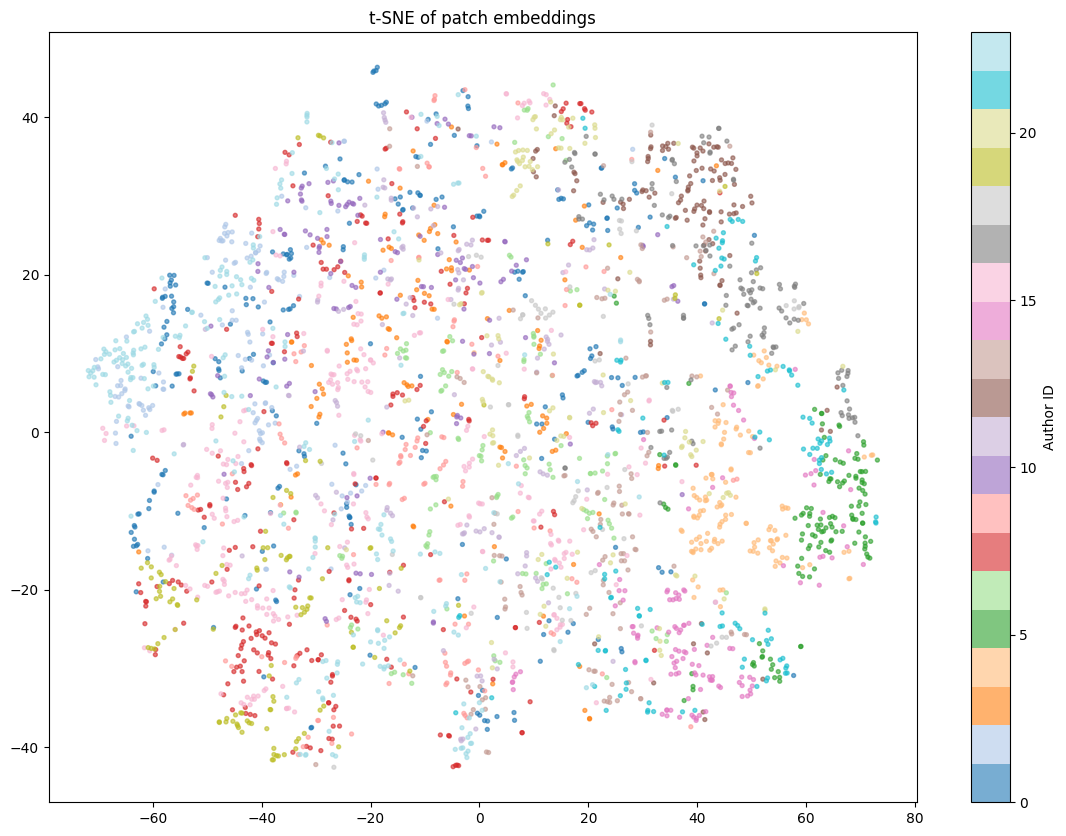

In [93]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

tsne = TSNE(
    n_components=2,
    perplexity=30,
    max_iter=1000,
    random_state=42,
)

emb_2d = tsne.fit_transform(embeddings)

plt.figure(figsize=(14, 10))
plt.scatter(
    emb_2d[:, 0],
    emb_2d[:, 1],
    c=author_ids,
    cmap="tab20",
    s=8,
    alpha=0.6,
)
plt.colorbar(label="Author ID")
plt.title("t-SNE of patch embeddings")
plt.show()

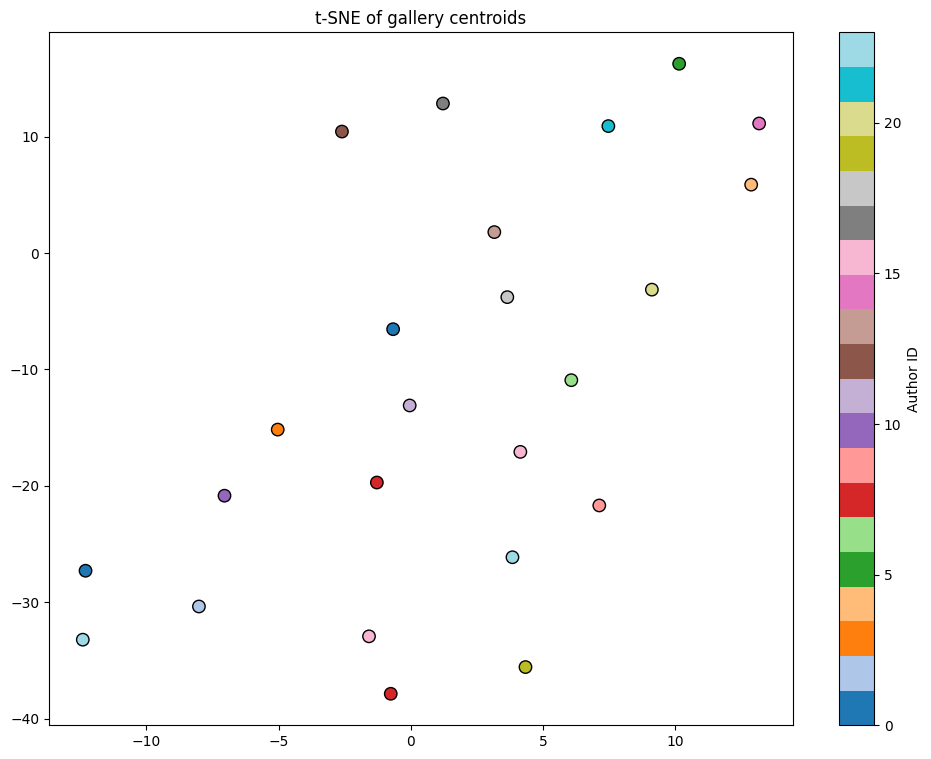

In [94]:
gallery_embeddings = np.stack(list(eval_gallery.values()))
gallery_author_ids = np.array(list(eval_gallery.keys()))

tsne = TSNE(
    n_components=2,
    perplexity=10,
    max_iter=1000,
    random_state=42,
)

gallery_2d = tsne.fit_transform(gallery_embeddings)

plt.figure(figsize=(12, 9))
plt.scatter(
    gallery_2d[:, 0],
    gallery_2d[:, 1],
    c=gallery_author_ids,
    cmap="tab20",
    s=80,
    edgecolors="black",
)
plt.colorbar(label="Author ID")
plt.title("t-SNE of gallery centroids")
plt.show()